In [ ]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
np.random.seed(42)
n = 100
coords = np.random.rand(n,2)
G = nx.random_geometric_graph(n, radius=0.2, pos={i:coords[i] for i in range(n)})
pos = nx.get_node_attributes(G,'pos')

In [ ]:
density = {}
for node in G.nodes():
    density[node] = len(list(G.neighbors(node)))

In [ ]:
parent = {i:i for i in G.nodes()}
def find(x):
    while parent[x] != x:
        x = parent[x]
    return x
def union(a,b):
    ra = find(a)
    rb = find(b)
    if ra != rb:
        parent[rb] = ra

In [ ]:
alpha = 1
beta = 1
gamma = 0.5
threshold = 2.5

In [ ]:
for u,v in G.edges():

    x1,y1 = pos[u]
    x2,y2 = pos[v]

    dist = np.sqrt((x1-x2)**2 + (y1-y2)**2)

    density_sim = 1/(1 + abs(density[u]-density[v]))

    score = alpha*1 + beta*(1/(dist+0.01)) + gamma*density_sim

    if score > threshold:
        union(u,v)

In [ ]:
communities = {}

for node in G.nodes():
    root = find(node)
    communities.setdefault(root,[]).append(node)

print("Number of communities:", len(communities))

Number of communities: 1


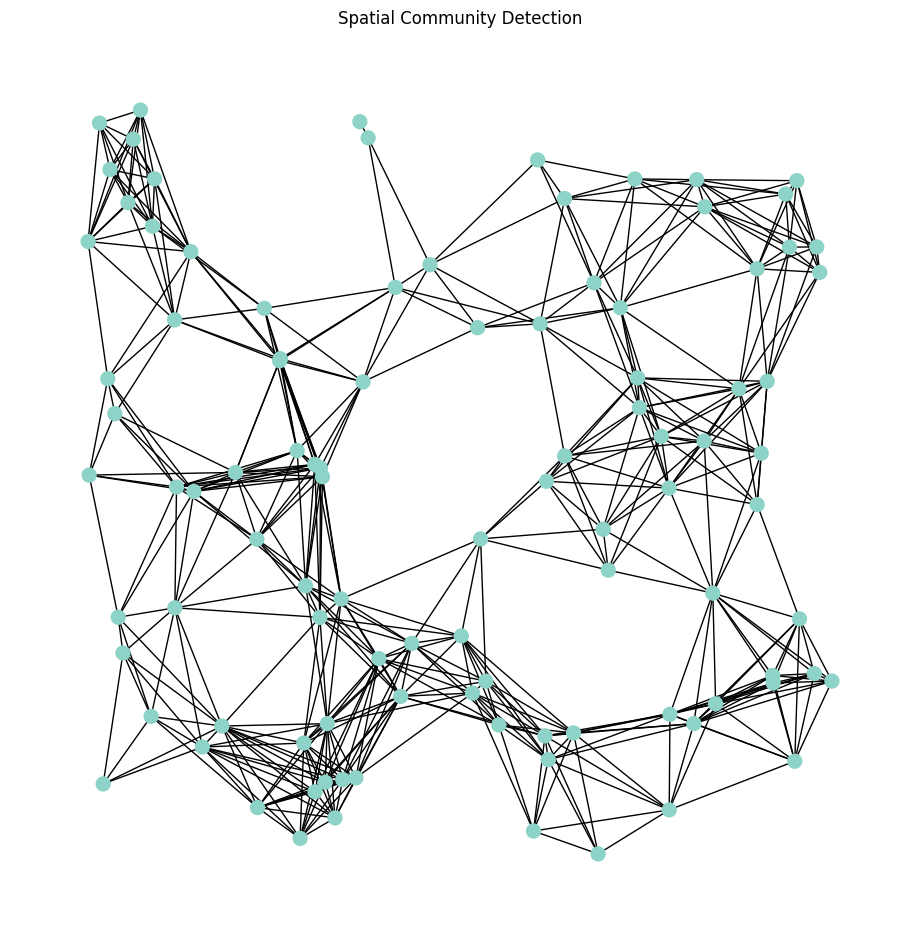

In [ ]:
colors = {}

for i,(k,v) in enumerate(communities.items()):
    for node in v:
        colors[node] = i

node_colors = [colors[node] for node in G.nodes()]

plt.figure(figsize=(9,9))
nx.draw(G,pos,node_color=node_colors,node_size=100,cmap=plt.cm.Set3)
plt.title("Spatial Community Detection")
plt.show()

In [ ]:
partition = {}

for cid, nodes in enumerate(communities.values()):
    for n in nodes:
        partition[n] = cid

modularity = nx.algorithms.community.quality.modularity(G, communities.values())

print("Modularity:", modularity)

Modularity: 0.0


In [ ]:
sizes = [len(v) for v in communities.values()]

print("Average cluster size:", np.mean(sizes))

Average cluster size: 100.0


In [ ]:
compactness = []

for nodes in communities.values():
    xs = [pos[n][0] for n in nodes]
    ys = [pos[n][1] for n in nodes]
    compactness.append(np.var(xs)+np.var(ys))

print("Average spatial variance:", np.mean(compactness))

Average spatial variance: 0.17303475244384722
